# Prompt engineering 
It is the practice of designing, structuring, and refining instructions so that artificial intelligence models like large language models produce accurate, relevant, and useful outputs. It bridges human intent and AI capability through clear context, roles, and formatting constraints.  
When you write a prompt, you are attempting to set up the LLM to predict the right sequence of tokens.  

Core Components of a Good Prompt:  

Instruction: The specific task you want the AI to perform.  
Context: Background information or the reason why you need the answer.  
Role/Character: Setting a persona for the AI (e.g., "Act as a financial advisor").  
Input Data: The raw text, data, or question the AI needs to process.  
Output Format: The desired structure of the response, such as a list, table, or word count limit.  



## Temperature  
temperature is a hyperparameter that controls the randomness of predictions. It scales the model's raw output scores (logits) before applying the softmax function. A lower temperature makes the model sharp and predictable, while a higher temperature spreads probabilities out for creative variety.  

How Temperature Works:  
Low Temperature (0.0 to 0.3): Divides logits to make top choices dominant; outputs become focused, factual, and deterministic.  
Medium Temperature (0.7 to 1.0): Balances standard predictability with natural variation.  
High Temperature (above 1.0): Flattens the probability distribution; outputs become diverse, creative, or potentially random and nonsensical.  

Low temperature → predictable, focused, consistent output.  
High temperature → diverse, creative, unexpected output.  
Temperature = 0 → selects the highest-probability token (greedy decoding).  
Higher temperature → lower-probability tokens get a greater chance of being selected.  
Very high temperature → tokens become more equally likely, making the output more random.  
Best for factual tasks → low temperature.  
Best for creative tasks → high temperature.  

## Top-K and Top-P in LLMs  
Top-K and Top-P are sampling techniques used in Large Language Models to control which tokens the model can choose from when generating text.

They are related to temperature, but they work differently.  
Top-K and Top-P control randomness and diversity in LLM output.  
Both restrict which tokens can be selected as the next token.  

Top-K limits the model to choosing from only the K most probable tokens.  

Higher K → more creative and varied output.  
Lower K → more focused and factual output.  
Top-K = 1 → greedy decoding (selects only the most likely token).  

Example

Suppose the model predicts:

AI → is       ->40%  
AI → can      ->25%  
AI → will     ->15%  
AI → helps    ->10%  
AI → learns    ->5%  
AI → creates   ->5%  
  
If:  

Top-K = 3

The model considers only:

is      ->40%  
can     ->25%  
will    ->15%  

The other tokens are ignored.    

**Top-P**, also called nucleus sampling, selects the smallest group of tokens whose cumulative probability reaches P.  

Lower P → more focused and predictable output.  
Higher P → more diverse and creative output.  
P = 0 → greedy decoding.  
P = 1 → all tokens can be considered.  

xample

Suppose:

is       = 40%  
can      = 25%  
will     = 15%  
helps    = 10%  
learns    = 5%  
creates   = 5%  

If:

Top-P = 0.80

We add probabilities:

is       = 40%   → 0.40   
can      = 25%   → 0.65  
will     = 15%   → 0.80  

So the model considers:

is
can
will

because their cumulative probability reaches 80%.

## Prompting techniques
### General prompting / Zero Short  
A zero-shot5 prompt is the simplest type of prompt. It only provides a description of a task and some text for the LLM to get started with. This input could be anything: a question, a start of a story, or instructions. The name zero-shot stands for ’no examples’.  

*Example*:

Classify the sentiment of this sentence:  
"I love this product."  

Use: Simple and straightforward tasks.

### One-shot & Few-shot  
**One-shot Prompting**
Give the model one example before asking it to perform the task.

*Example*:  
Positive: "I love this phone."  
Classify:  
"This laptop is amazing."  

Use: When you want to demonstrate the expected pattern.

**Few-Shot Prompting**

Give the model multiple examples.

*Example*:  
Positive: "This movie is excellent."  
Negative: "This movie is terrible."  
Neutral: "The movie was released yesterday."  
Classify:  
"This movie was fantastic."   

Use: Classification, formatting, and tasks where examples help the model understand the pattern.

### System Prompting
A system prompt defines the overall behavior, rules, role, and limitations of the AI.

It usually has higher priority than the user's normal prompt.

*Example*:

You are a helpful Python tutor.  
Always explain concepts in simple English.  
Give examples when appropriate.  
Do not provide unnecessarily complicated explanations.  

Then the user asks:  
Explain LSTM.

The system prompt controls how the model should behave while answering.    
Used for: AI assistants, chatbots, customer-support systems, applications.  

### Contextual Prompting
Contextual prompting provides the model with relevant background information or additional context before asking it to perform a task.

*Example*:  
Without context:  

Explain this problem.

With context:  

I am a beginner learning machine learning.  
I already understand linear regression but  
do not understand classification.  

Explain logistic regression using this background.

The second prompt gives the model information about the user's knowledge and situation.  
Used for: RAG, document Q&A, personalized assistants, customer support.

### Role Prompting
Role prompting tells the model to behave like a particular person, expert, or professional.

*Example*:  
You are a senior machine learning engineer.

Explain Random Forest to a beginner.  
Give a simple example and mention its advantages and disadvantages.  

Here: "You are a senior machine learning engineer" is the role instruction.

### Step-Back Prompting 
It is a technique for improving the performance by prompting the LLM to first consider a general question related to the specific task at hand, and then feeding the answer to that general question into a subsequent prompt for the specific task. This ‘step back’ allows the LLM to activate relevant background knowledge and reasoning processes before attempting to solve the specific problem.  

*Example*:  
Instead of immediately solving:

Why did this particular machine learning model fail?  

First ask:

What are the general reasons why machine learning models fail or perform poorly?  

Then apply those principles:

Based on those general principles, analyze why this particular model failed.

### Chain-of-Thought (CoT) Prompting
Chain-of-Thought (CoT) prompting is a prompting technique that encourages an LLM to solve a complex problem through multiple intermediate reasoning steps rather than jumping directly to the final answer.  

*Simple Example*:

Instead of:

What is 25 × 18?

Use:

Solve the problem step by step and provide the final answer.

What is 25 × 18?

The model can break it into smaller steps:

25 × 18  
= 25 × (20 - 2)  
= 500 - 50  
= 450  

CoT is particularly useful for:

Mathematical problems  
Logical reasoning  
Multi-step problems  
Complex decision-making  
Programming/debugging  
Data analysis  

CoT has a lot of advantages. First of all, it’s low-effort while being very effective and works well with off-the-shelf LLMs (so no need to finetune). You also get interpretability with CoT prompting, as you can learn from the LLM’s responses and see the reasoning steps that were followed. If there’s a malfunction, you will be able to identify.

### Self-Consistency
Self-Consistency is a prompting technique where the model generates multiple possible reasoning paths for the same problem and then selects the answer that appears most consistently.  

*Example*:  
Solve the problem using multiple possible approaches.  
Compare the results and give the most consistent answer.  

How it works: It gives different approaches for the same question and then selects the most consistent answer among them.  

Extracts the final answer from each response.  
Selects the most common answer as the final answer.  
Provides a pseudo-probability that the answer is correct.  

Use: Mathematical problems, logical reasoning, and problems where multiple solution paths are possible.

### Tree of Thoughts (ToT)

Tree of Thoughts explores multiple branches of reasoning and evaluates them to find the best solution. It allows LLMs to explore multiple different reasoning paths simultaneously, rather than just following a single linear chain of thought. 

Workflow:  
**Decomposition**: Split the main problem into smaller, manageable steps or thoughts.  
**Generation**: Create multiple diverse or sequential candidate thoughts for each step.  
**Evaluation**: Assess the progress of each branch (e.g., scoring them as promising, weak, or a dead end).  
**Search**: Apply search algorithms like Breadth-First Search (BFS) or Depth-First Search (DFS) to navigate the tree and pursue the best path.

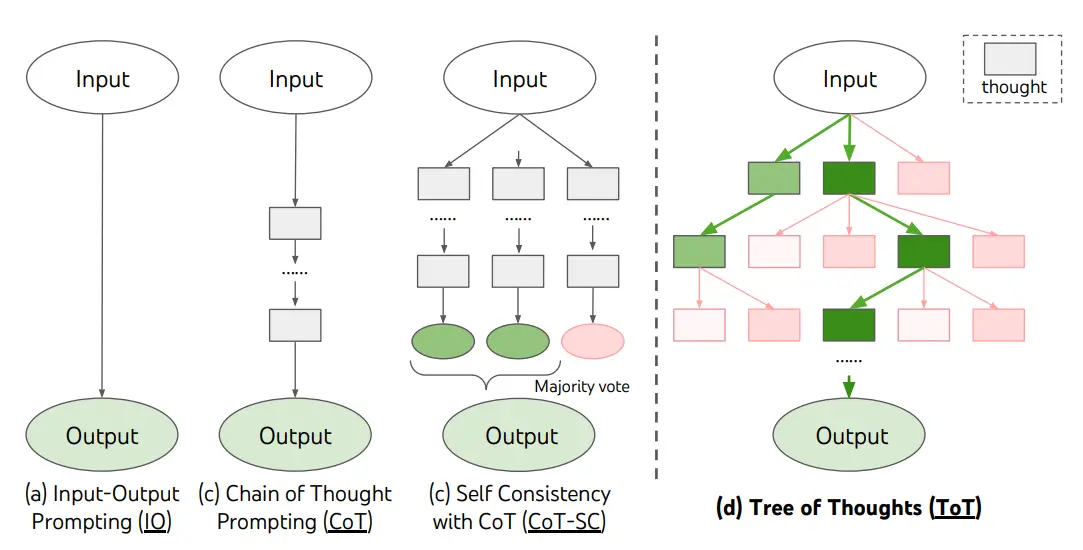 

### ReAct — Reason + Act  
ReAct (Reasoning + Acting) is a prompting technique where an AI combines step-by-step reasoning with actions through external tools, allowing it to think through a problem and take steps to solve it.

Breaks complex problems into steps and decides actions at each stage  
Uses results from actions (observations) to refine and improve future decisions  
Used in chatbots, robotics, and automation  

*Example*  
User:  
What is the weather in New York today?

AI:  
I need current weather information.

Action:  
Use weather API.

Observation:  
Temperature = 78°F

Final:  
The current temperature is 78°F.

### Instruction Prompting
Instruction prompting gives the LLM a clear and explicit instruction about what task it should perform.  

*Example*:  
Summarize the following paragraph in 3 bullet points.  
Use simple English.  
                            
Here, the instructions specify:

Task: Summarize  
Length: 3 points  
Language/style: Simple English   
Format: Bullet points  

### Automatic Prompt Engineering
Automatic Prompt Engineering (APE) is a technique where an AI system automatically generates, evaluates, and improves prompts instead of a human manually designing them.  

How Auto Prompting Works  
Seed Prompt: You start with a basic, rough idea or goal.  
Generation & Search: An LLM or search algorithm creates multiple candidate variations using mutation or meta-prompting.  
Evaluation: The system tests these candidate prompts against validation datasets or using an LLM-as-a-judge to score performance.  
Refinement: The best prompts are kept, modified, or combined until the output quality converges on a target metric.  

*Example*:  
Suppose the task is:

Classify customer reviews as Positive or Negative.

APE might automatically generate:

Prompt 1:  
Classify the sentiment of this review.

Prompt 2:  
Determine whether this review expresses positive or negative sentiment.

Prompt 3:  
Analyze the customer review and classify it as Positive or Negative.

The system tests these prompts against a validation dataset:

Prompt 1 → Accuracy = 82%  
Prompt 2 → Accuracy = 88%  
Prompt 3 → Accuracy = 91%  

It selects:

Best Prompt → Prompt 3

### Code Prompting
Code prompting is a technique where an LLM is given instructions to generate, explain, debug, modify, or optimize code.

*Example*:  
User:  
"Write Python code to calculate the average of a list of numbers."

LLM:  
```python  
numbers = [10, 20, 30, 40, 50]  
average = sum(numbers) / len(numbers)  
print(average)  


### Code Prompting Flow

Programming Task
       ↓
Give Instructions to LLM
       ↓
Generate Code
       ↓
Run / Test Code
       ↓
Check Result
       ↓
Debug or Improve

### Multimodal Prompting
Multimodal prompting is a technique where the model receives multiple types of input, such as text, images, audio, or video, and uses them together to generate a response.

Example

Give the model an image of a graph along with a text instruction:

Image: [Sales graph]

Prompt:  
"Analyze this graph and explain which month had the highest sales."   

The model uses:
``` text
Image + Text  
    ↓  
Multimodal LLM  
    ↓  
Understand both inputs  
    ↓  
Generate Answer  

### Controlling Maximum Token Length
Max token length controls the maximum number of tokens an LLM can generate in its response.

A token can be a word, part of a word, punctuation mark, or symbol.  

*Example*:

max_tokens = 50
``` text
Prompt
   ↓
LLM
   ↓
Generate up to 50 tokens
   ↓
Stop
```  
Small max_tokens → Short response  
Large max_tokens → Longer response

## Prompt Fine-Tuning Techniques

### Manual Prompt Optimization
Manual Prompt Optimization is the process of manually improving a prompt based on the model's output.  
*Example*:

Suppose you want an LLM to explain LSTM.

Prompt 1:  
Explain LSTM.

Output may be too technical.

So we improve the prompt:

Prompt 2:  
Explain LSTM in simple English.

Still, we want an example.

Prompt 3:  
Explain LSTM in simple English.  
Give a simple real-world example and mention its advantages.

Now the output is more useful.

Flow:
```text
Initial Prompt
      ↓
Check Output
      ↓
Find Problems
      ↓
Improve Prompt
      ↓
Check Output Again
      ↓
Better Prompt

### Automatic Prompt Optimization
Automatic Prompt Optimization means a system automatically creates and tests different versions of a prompt to find the best one.

*Example*:

Task:  
Classify customer reviews as Positive or Negative.

The system generates:

Prompt 1:  
Classify the sentiment.

Prompt 2:  
Determine whether the review is positive or negative.

Prompt 3:  
Analyze the review and classify its sentiment as
Positive or Negative.

It tests them:

Prompt 1 → Accuracy = 80%  
Prompt 2 → Accuracy = 87%  
Prompt 3 → Accuracy = 92%  

So:

Best Prompt → Prompt 3
Flow:  
```text
Task
 ↓
Generate Prompts
 ↓
Test Prompts
 ↓
Evaluate Performance
 ↓
Select Best Prompt

### Soft Prompt Tuning
Instead of manually writing the perfect prompt, the model learns special numerical vectors called soft prompts.

Normally:  
"Explain machine learning"

With soft prompt tuning:  
[Learned Vectors] + "Explain machine learning"

The learned vectors are not normal English words. They are numerical representations that help guide the model.  

*Easy example*:  

Imagine teaching a student.

Normal prompting:

"Answer questions like a machine learning expert."

Soft prompt tuning:

Give the student a small set of learned instructions that automatically guide how they answer.

### Prefix Tuning

Prefix tuning is similar to soft prompt tuning, but the learned prefix is added to the model's processing at multiple layers.

Simple idea

Think of the LLM as having several layers:
``` text
Input
 ↓
Layer 1
 ↓
Layer 2
 ↓
Layer 3
 ↓
Output

Prefix tuning adds learned information throughout the model:

Input
 ↓
[Prefix] → Layer 1
 ↓
[Prefix] → Layer 2
 ↓
[Prefix] → Layer 3
 ↓
Output
```
*Example*:

Suppose you want a general LLM to become better at medical text summarization.

Instead of retraining the entire model:
```text
Medical Data
     ↓
Learn Prefix
     ↓
Frozen LLM
     ↓
Medical Summary

### Prompt Tuning
Prompt tuning trains a small set of continuous prompt embeddings while keeping the main LLM frozen.

*Example*:  
Suppose you have a large LLM and want it to perform better at:

Customer sentiment classification.

Instead of modifying the whole model:

Large LLM → Frozen  
Prompt Embeddings → Trainable

Training looks like:
```text
Customer Review
      ↓
Learned Prompt
      ↓
Frozen LLM
      ↓
Positive / Negative  
```
*Example*:

Input:  
"The product is excellent."

The learned prompt helps the model produce:

Positive

### Instruction Tuning

Instruction tuning trains an LLM using many instruction + response examples so that it becomes better at following instructions.

*Example*:  
Training data:

Instruction:  
Translate "Hello" into Spanish.

Response:   
Hola.  

Flow:
```text
Instructions + Correct Responses
              ↓
           Training
              ↓
      Instruction-Tuned LLM
              ↓
      Better Instruction Following

### Few-Shot Prompt Optimization

Few-shot prompting gives the model examples. Few-shot prompt optimization focuses on selecting or improving those examples to get better performance.

*Example*:  
Instead of:

Classify this review:  
"The phone is amazing."

Give examples:

"I love this phone." → Positive  
"This phone is terrible." → Negative  
"I bought this phone yesterday." → Neutral  

Now classify:  
"This phone is excellent."

The model uses the examples to understand the task.

Optimization:  

You might test different examples:

Examples Set 1 → Accuracy = 78%  
Examples Set 2 → Accuracy = 86%  
Examples Set 3 → Accuracy = 93%  

Choose:

Best Examples → Set 3

### Quick Comparison

1. Manual Prompt Optimization
   → Human improves the prompt

2. Automatic Prompt Optimization
   → System automatically finds a better prompt

3. Soft Prompt Tuning
   → Learn numerical prompt vectors

4. Prefix Tuning
   → Learn prefixes that guide multiple model layers

5. Prompt Tuning
   → Learn continuous prompt embeddings

6. Instruction Tuning
   → Train the LLM using instruction-response examples

7. Few-Shot Prompt Optimization
   → Select the best examples for the prompt